In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler
from sklearn.naive_bayes import ComplementNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from scipy import stats
from sklearn.base import clone
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix 
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [85]:
# !pip install pandas-profiling

In [86]:
## Read the data
df = pd.read_excel('Bank_Personal_Loan_Modelling.xlsx',sheet_name='Data')
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [87]:
df.drop('ID', axis=1, inplace=True)

In [88]:
df.shape

(5000, 13)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [90]:
df.columns

Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [91]:
## Change data types
df['ZIP Code'] = df['ZIP Code'].astype('object')
df['Education']=df['Education'].astype('object')
df['Securities Account'] = df['Securities Account'].astype('object')
df['CD Account']=df['CD Account'].astype('object')
df['Online']=df['Online'].astype('object')
df['CreditCard']=df['CreditCard'].astype('object')

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   object 
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   object 
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   object 
 10  CD Account          5000 non-null   object 
 11  Online              5000 non-null   object 
 12  CreditCard          5000 non-null   object 
dtypes: float64(1), int64(6), object(6)
memory usage: 507.9+ KB


In [93]:
df.isna().sum()

Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.describe()

,Age,Experience,Income,Family,CCAvg,Mortgage,Personal Loan
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937913,56.498800,0.096000
std,11.463166,11.467954,46.033729,1.147663,1.747666,101.713802,0.294621
min,23.000000,-3.000000,8.000000,1.000000,0.000000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,0.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,101.000000,0.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,635.000000,1.000000


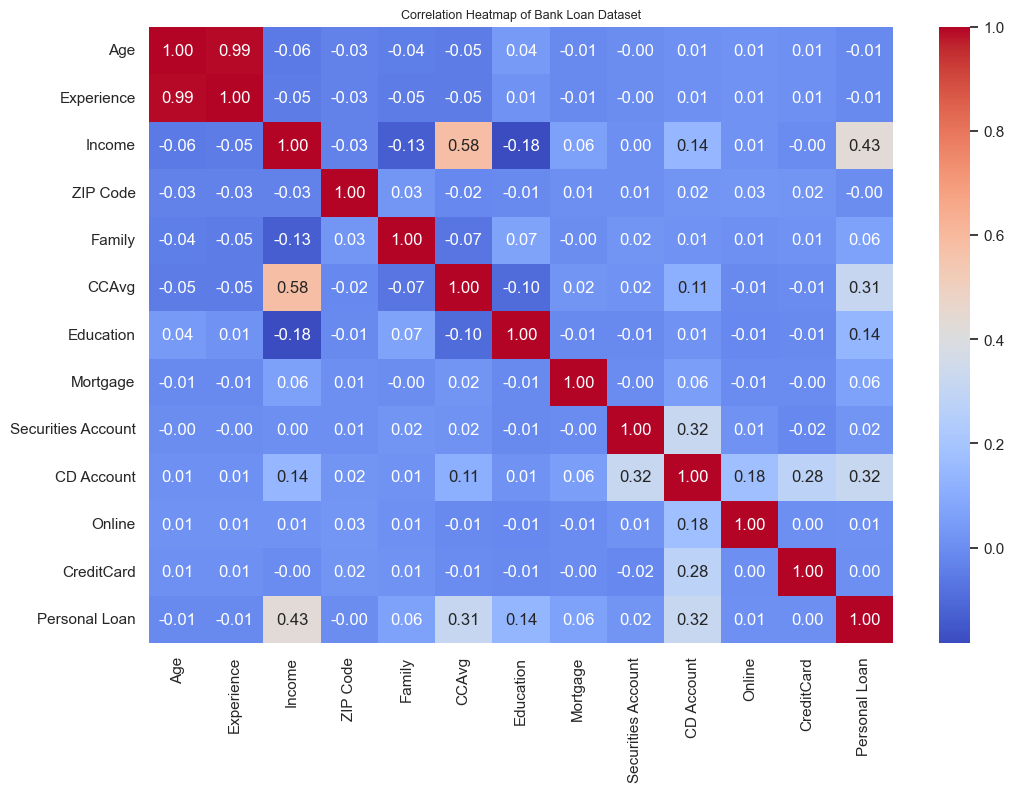

In [96]:
# Calculation of the Pearson correlation - for numerical variables
target = 'Personal Loan'
df1 = pd.concat([df.drop(target,axis=1), df[target]],axis=1)
num_df = df1.select_dtypes(include=['int64', 'float64'])
corr = df1.corr(method='spearman')

# Set figure size
plt.figure(figsize=(12,8))

# Create heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Add title
plt.title("Correlation Heatmap of Bank Loan Dataset", fontsize=9)
plt.show()

#### Coorelation Finding: 
##### Age and experience are highly positively correlated 
##### Income is moderately correlated with CCAvg and Personal Loan

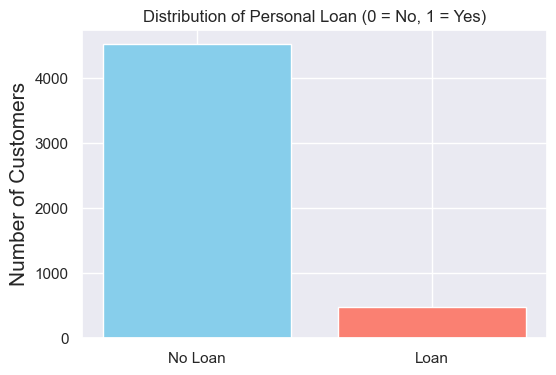

In [97]:
# Count of each category
counts = df['Personal Loan'].value_counts()

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['skyblue','salmon'])
plt.xticks([0,1], ['No Loan', 'Loan'])
plt.ylabel("Number of Customers")
plt.title("Distribution of Personal Loan (0 = No, 1 = Yes)")
plt.show()


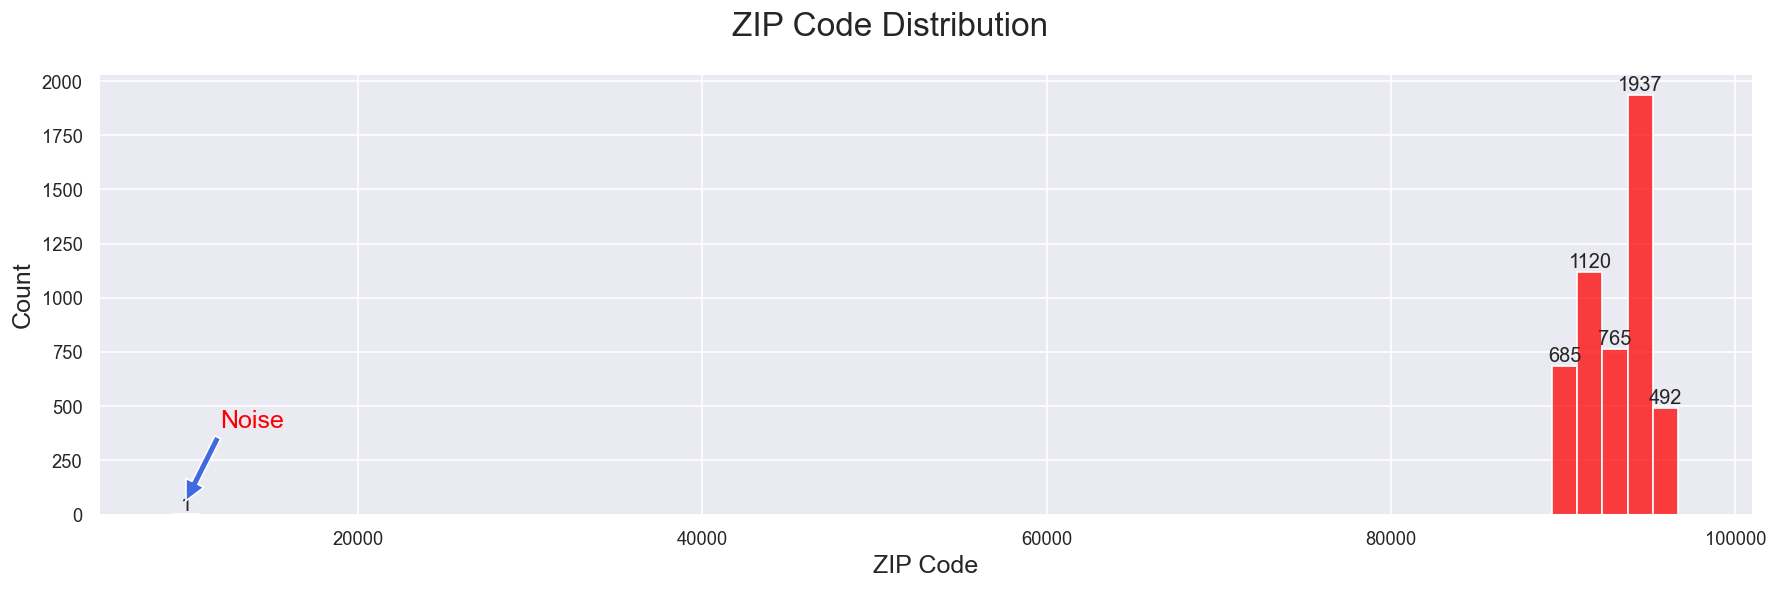

In [98]:
## Distribution of the Zip Code
sns.set_style('darkgrid')
color = 'royalblue'

# Plot histogram
plt.figure(figsize=(15,5), dpi=120)
graph = sns.histplot(x='ZIP Code', data=df, bins=60, color='red')

# Show non-zero values of the individual bars
labels = [str(v) if v else '' for v in graph.containers[0].datavalues]
graph.bar_label(graph.containers[0], labels=labels)

plt.annotate('Noise', xy=(10000,60), xytext=(12000,400), color='red', fontsize=15, 
             arrowprops=dict(facecolor=color, shrink=0.01))
plt.xlabel('ZIP Code', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.suptitle('ZIP Code Distribution', fontsize=20)
plt.tight_layout()
plt.show()

In [99]:
df[df['ZIP Code']<20000]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
384,51,25,21,9307,4,0.6,3,0,0,0,0,1,1


In [100]:
df.drop(df[df['ZIP Code']<20000].index, inplace=True)
df.reset_index(drop=True, inplace =True)

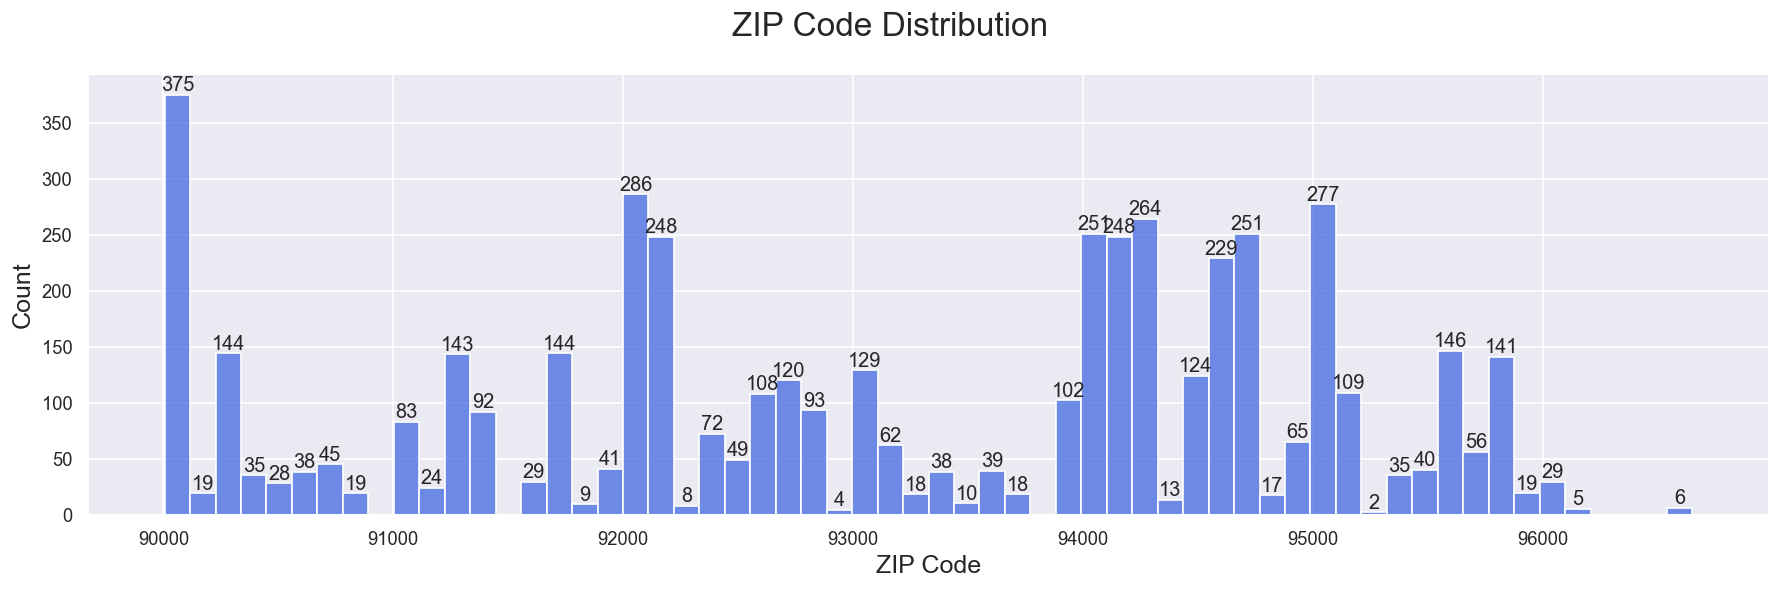

In [101]:
## Distribution of the Zip Code after removing the outlier
sns.set_style('darkgrid')
color = 'royalblue'

# Plot histogram
plt.figure(figsize=(15,5), dpi=120)
graph = sns.histplot(x='ZIP Code', data=df, bins=60, color=color)

# Show non-zero values of the individual bars
labels = [str(v) if v else '' for v in graph.containers[0].datavalues]
graph.bar_label(graph.containers[0], labels=labels)
plt.xlabel('ZIP Code', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.suptitle('ZIP Code Distribution', fontsize=20)
plt.tight_layout()
plt.show()

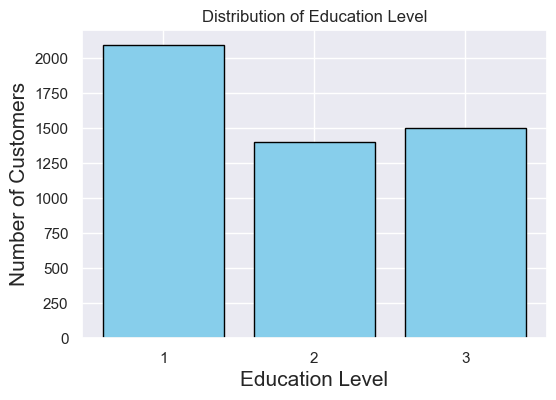

In [102]:
## Distribution of the Education

counts_ED = df['Education'].value_counts().sort_index()  # sorts 1,2,3

plt.figure(figsize=(6,4))
plt.bar(counts_ED.index.astype(str), counts_ED.values, color='skyblue', edgecolor='black')
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.title("Distribution of Education Level")
plt.show()

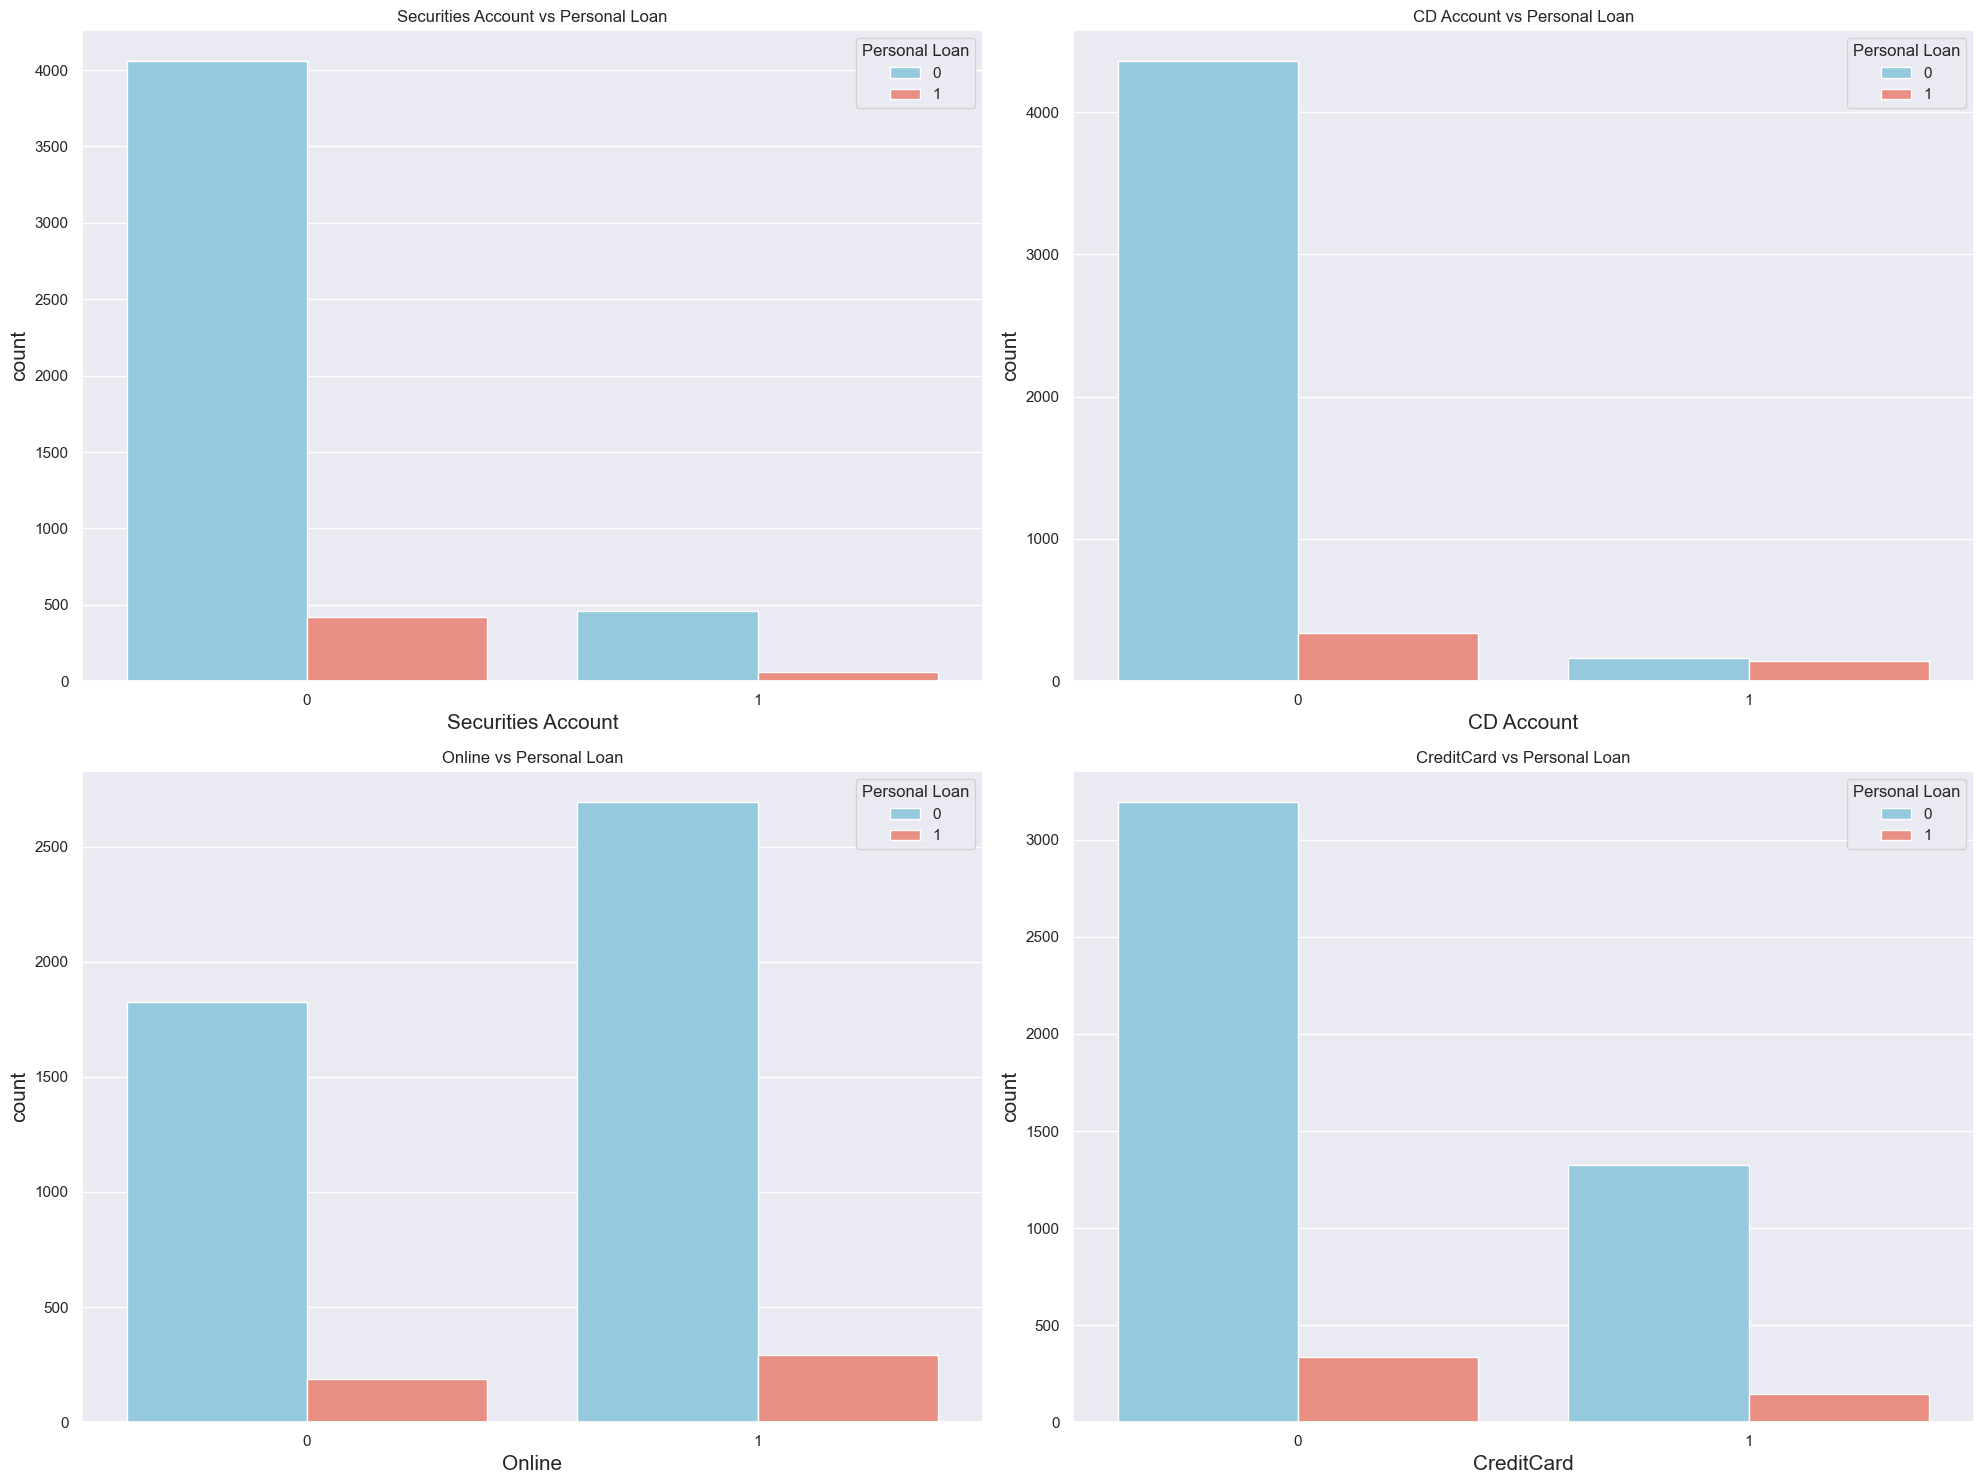

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables
cat_cols =['Securities Account', 'CD Account', 'Online', 'CreditCard']

target = "Personal Loan"

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20,15))
axes = axes.flatten()

# Loop
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue=target, ax=axes[i])
    axes[i].set_title(f"{col} vs {target}")
    axes[i].tick_params(axis='x')

plt.tight_layout()
plt.show()

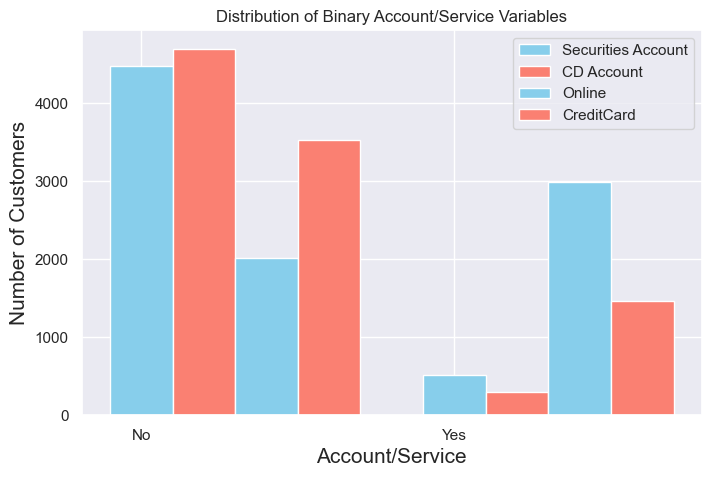

In [104]:
# Select the 4 columns
cols = ['Securities Account', 'CD Account', 'Online', 'CreditCard']

# Count of 0/1 for each column
counts = [df[col].value_counts().sort_index() for col in cols]

# Set positions for bars
x = np.arange(2)  # 0 and 1
width = 0.2

plt.figure(figsize=(8,5))

for i, count in enumerate(counts):
    plt.bar(x + i*width, count.values, width=width, label=cols[i])

plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel("Account/Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Binary Account/Service Variables")
plt.legend()
plt.show()

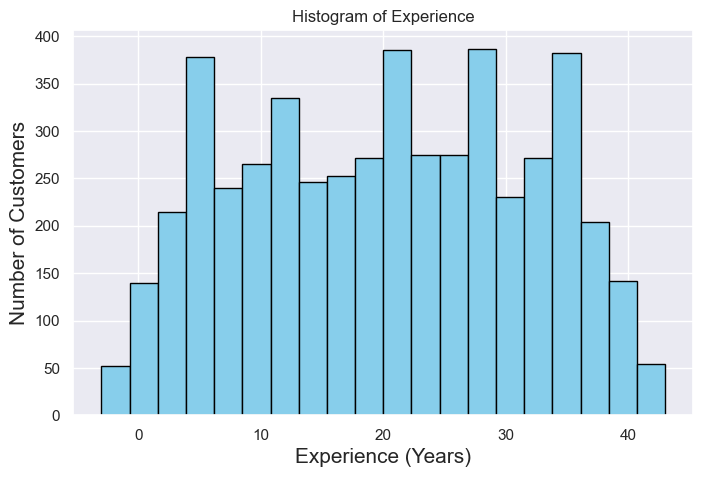

In [105]:
## Distribution of Experience

plt.figure(figsize=(8,5))
plt.hist(df['Experience'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Customers")
plt.title("Histogram of Experience")
plt.show()

In [106]:
## Since experience bars starts before 0, there should be negative experience values recorded in the data.
df[df['Experience']<0]['Experience'].value_counts()

Experience
-1    33
-2    15
-3     4
Name: count, dtype: int64

In [107]:
df['Experience'] = df['Experience'].apply(abs)

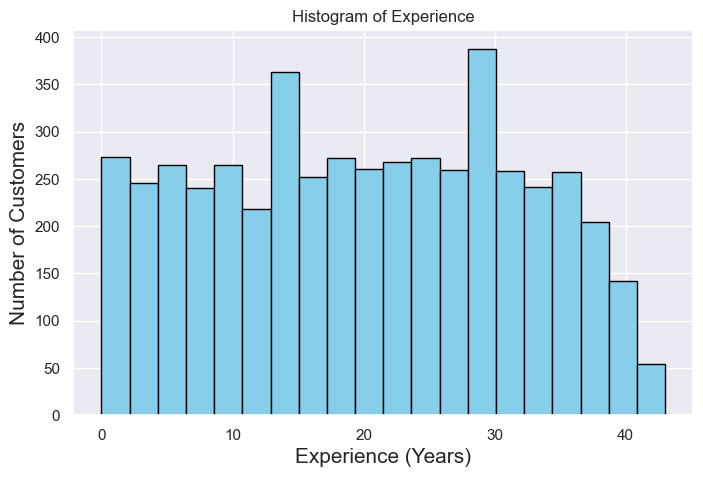

In [108]:
## Distribution of Experience after applying abs 

plt.figure(figsize=(8,5))
plt.hist(df['Experience'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Customers")
plt.title("Histogram of Experience")
plt.show()

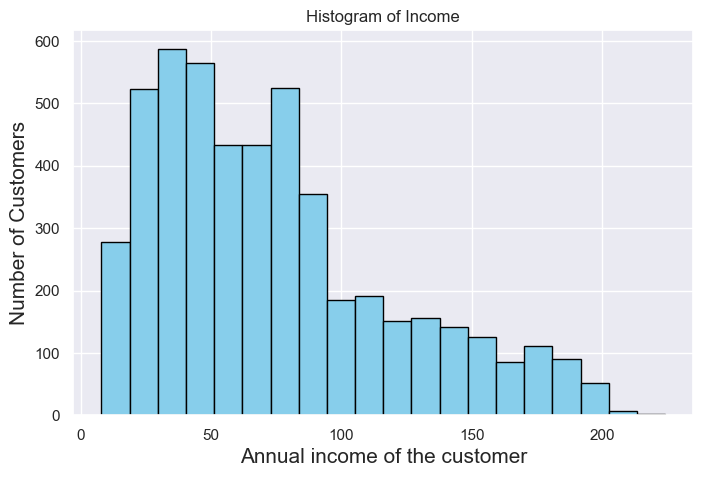

In [109]:
## Distribution of Experience after applying abs 

plt.figure(figsize=(8,5))
plt.hist(df['Income'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Annual income of the customer")
plt.ylabel("Number of Customers")
plt.title("Histogram of Income")
plt.show()

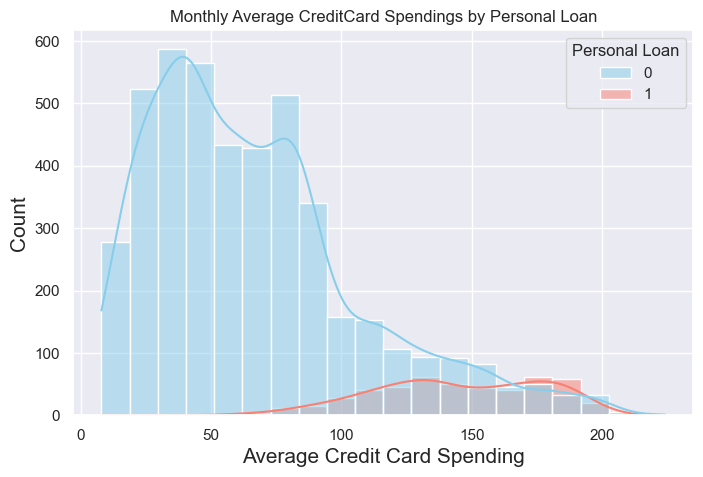

In [110]:
## Average Credit Card Spending vs. Personal Loan
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Income', hue='Personal Loan', bins=20, kde=True)
plt.xlabel("Average Credit Card Spending")
plt.ylabel("Count")
plt.title("Monthly Average CreditCard Spendings by Personal Loan")
plt.show()

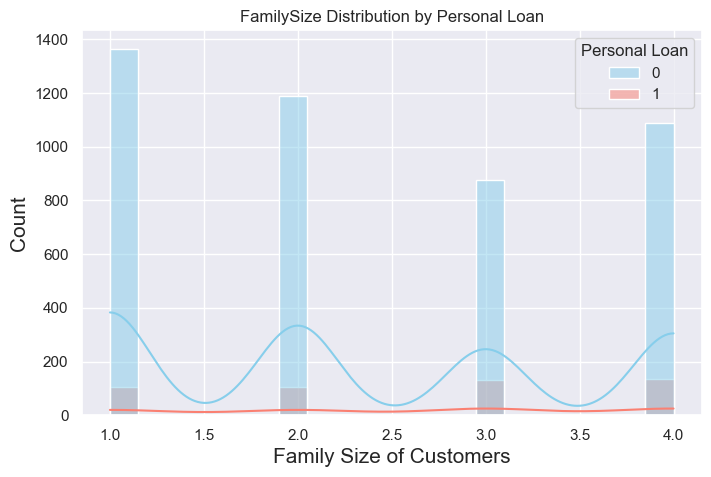

In [111]:
## Income vs. Personal Loan
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Family', hue='Personal Loan', bins=20, kde=True)
plt.xlabel("Family Size of Customers")
plt.ylabel("Count")
plt.title("FamilySize Distribution by Personal Loan")
plt.show()

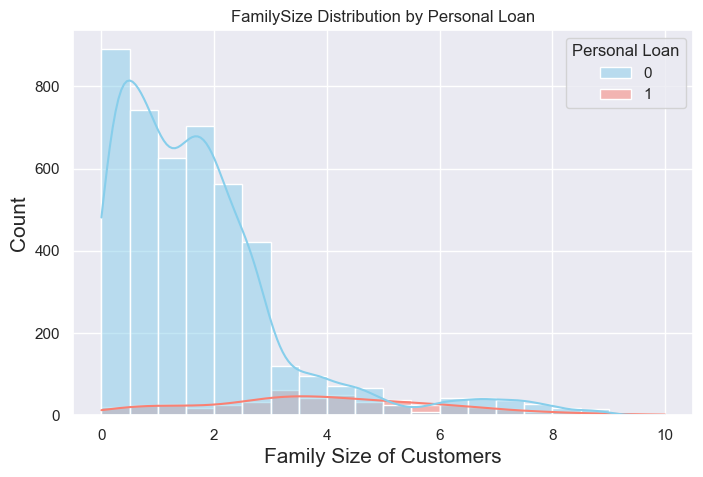

In [112]:
## Income vs. Personal Loan
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='CCAvg', hue='Personal Loan', bins=20, kde=True)
plt.xlabel("Family Size of Customers")
plt.ylabel("Count")
plt.title("FamilySize Distribution by Personal Loan")
plt.show()

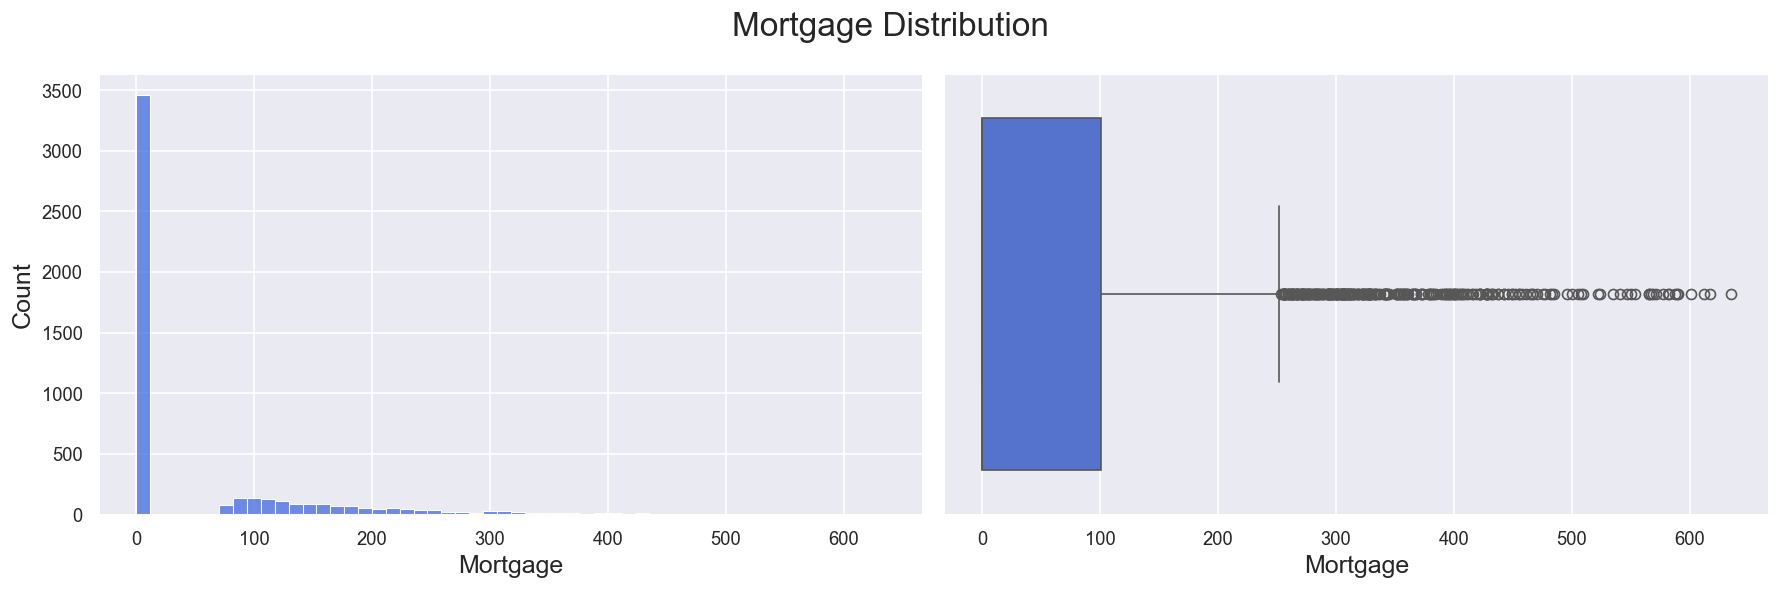

In [113]:
#Distribution of Mortgage
sns.set(rc = {'axes.labelsize' : 15})               
fig, ax = plt.subplots(1, 2, figsize=(15,5), dpi=120)
sns.histplot(x='Mortgage', data=df, color='royalblue', ax=ax[0])
sns.boxplot(x='Mortgage', data=df, color='royalblue', ax=ax[1])
plt.suptitle('Mortgage Distribution', fontsize=20)
plt.tight_layout()
plt.show()

In [114]:
df[stats.zscore(df['Mortgage'])>3]['Mortgage'].count()

np.int64(105)

In [115]:
#Outlier treatment for mortgage
outlier_indexes = df[stats.zscore(df['Mortgage'])>3].index
df.drop(outlier_indexes, inplace=True)
df.reset_index(drop=True, inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_14432\2132674686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Personal Loan', y='Mortgage', data=df, palette=['skyblue','salmon'])


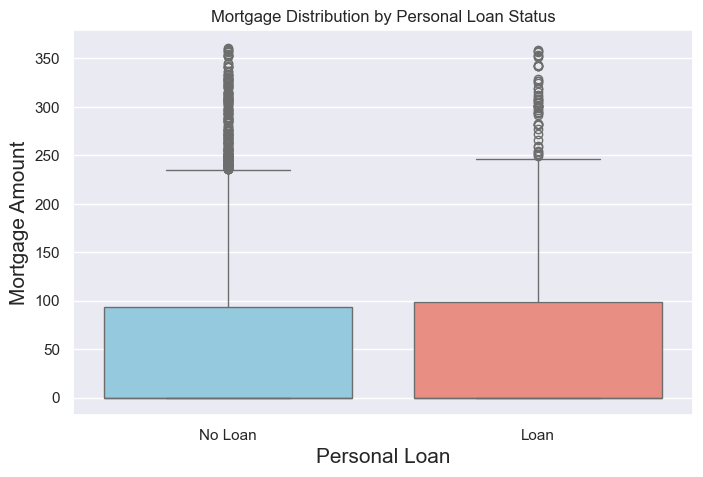

In [116]:
#Plot house mortgage vs personal loan
plt.figure(figsize=(8,5))
sns.boxplot(x='Personal Loan', y='Mortgage', data=df, palette=['skyblue','salmon'])
plt.xticks([0,1], ['No Loan','Loan'])
plt.ylabel("Mortgage Amount")
plt.xlabel("Personal Loan")
plt.title("Mortgage Distribution by Personal Loan Status")
plt.show()

In [117]:
### In the dataset, CCAVG represents average monthly credit card spending, but Income represents the amount of annual income.
### To make the units of the features equal, we convert average monthly credit card spending to annual:
df['CCAvg'] = df['CCAvg']*12

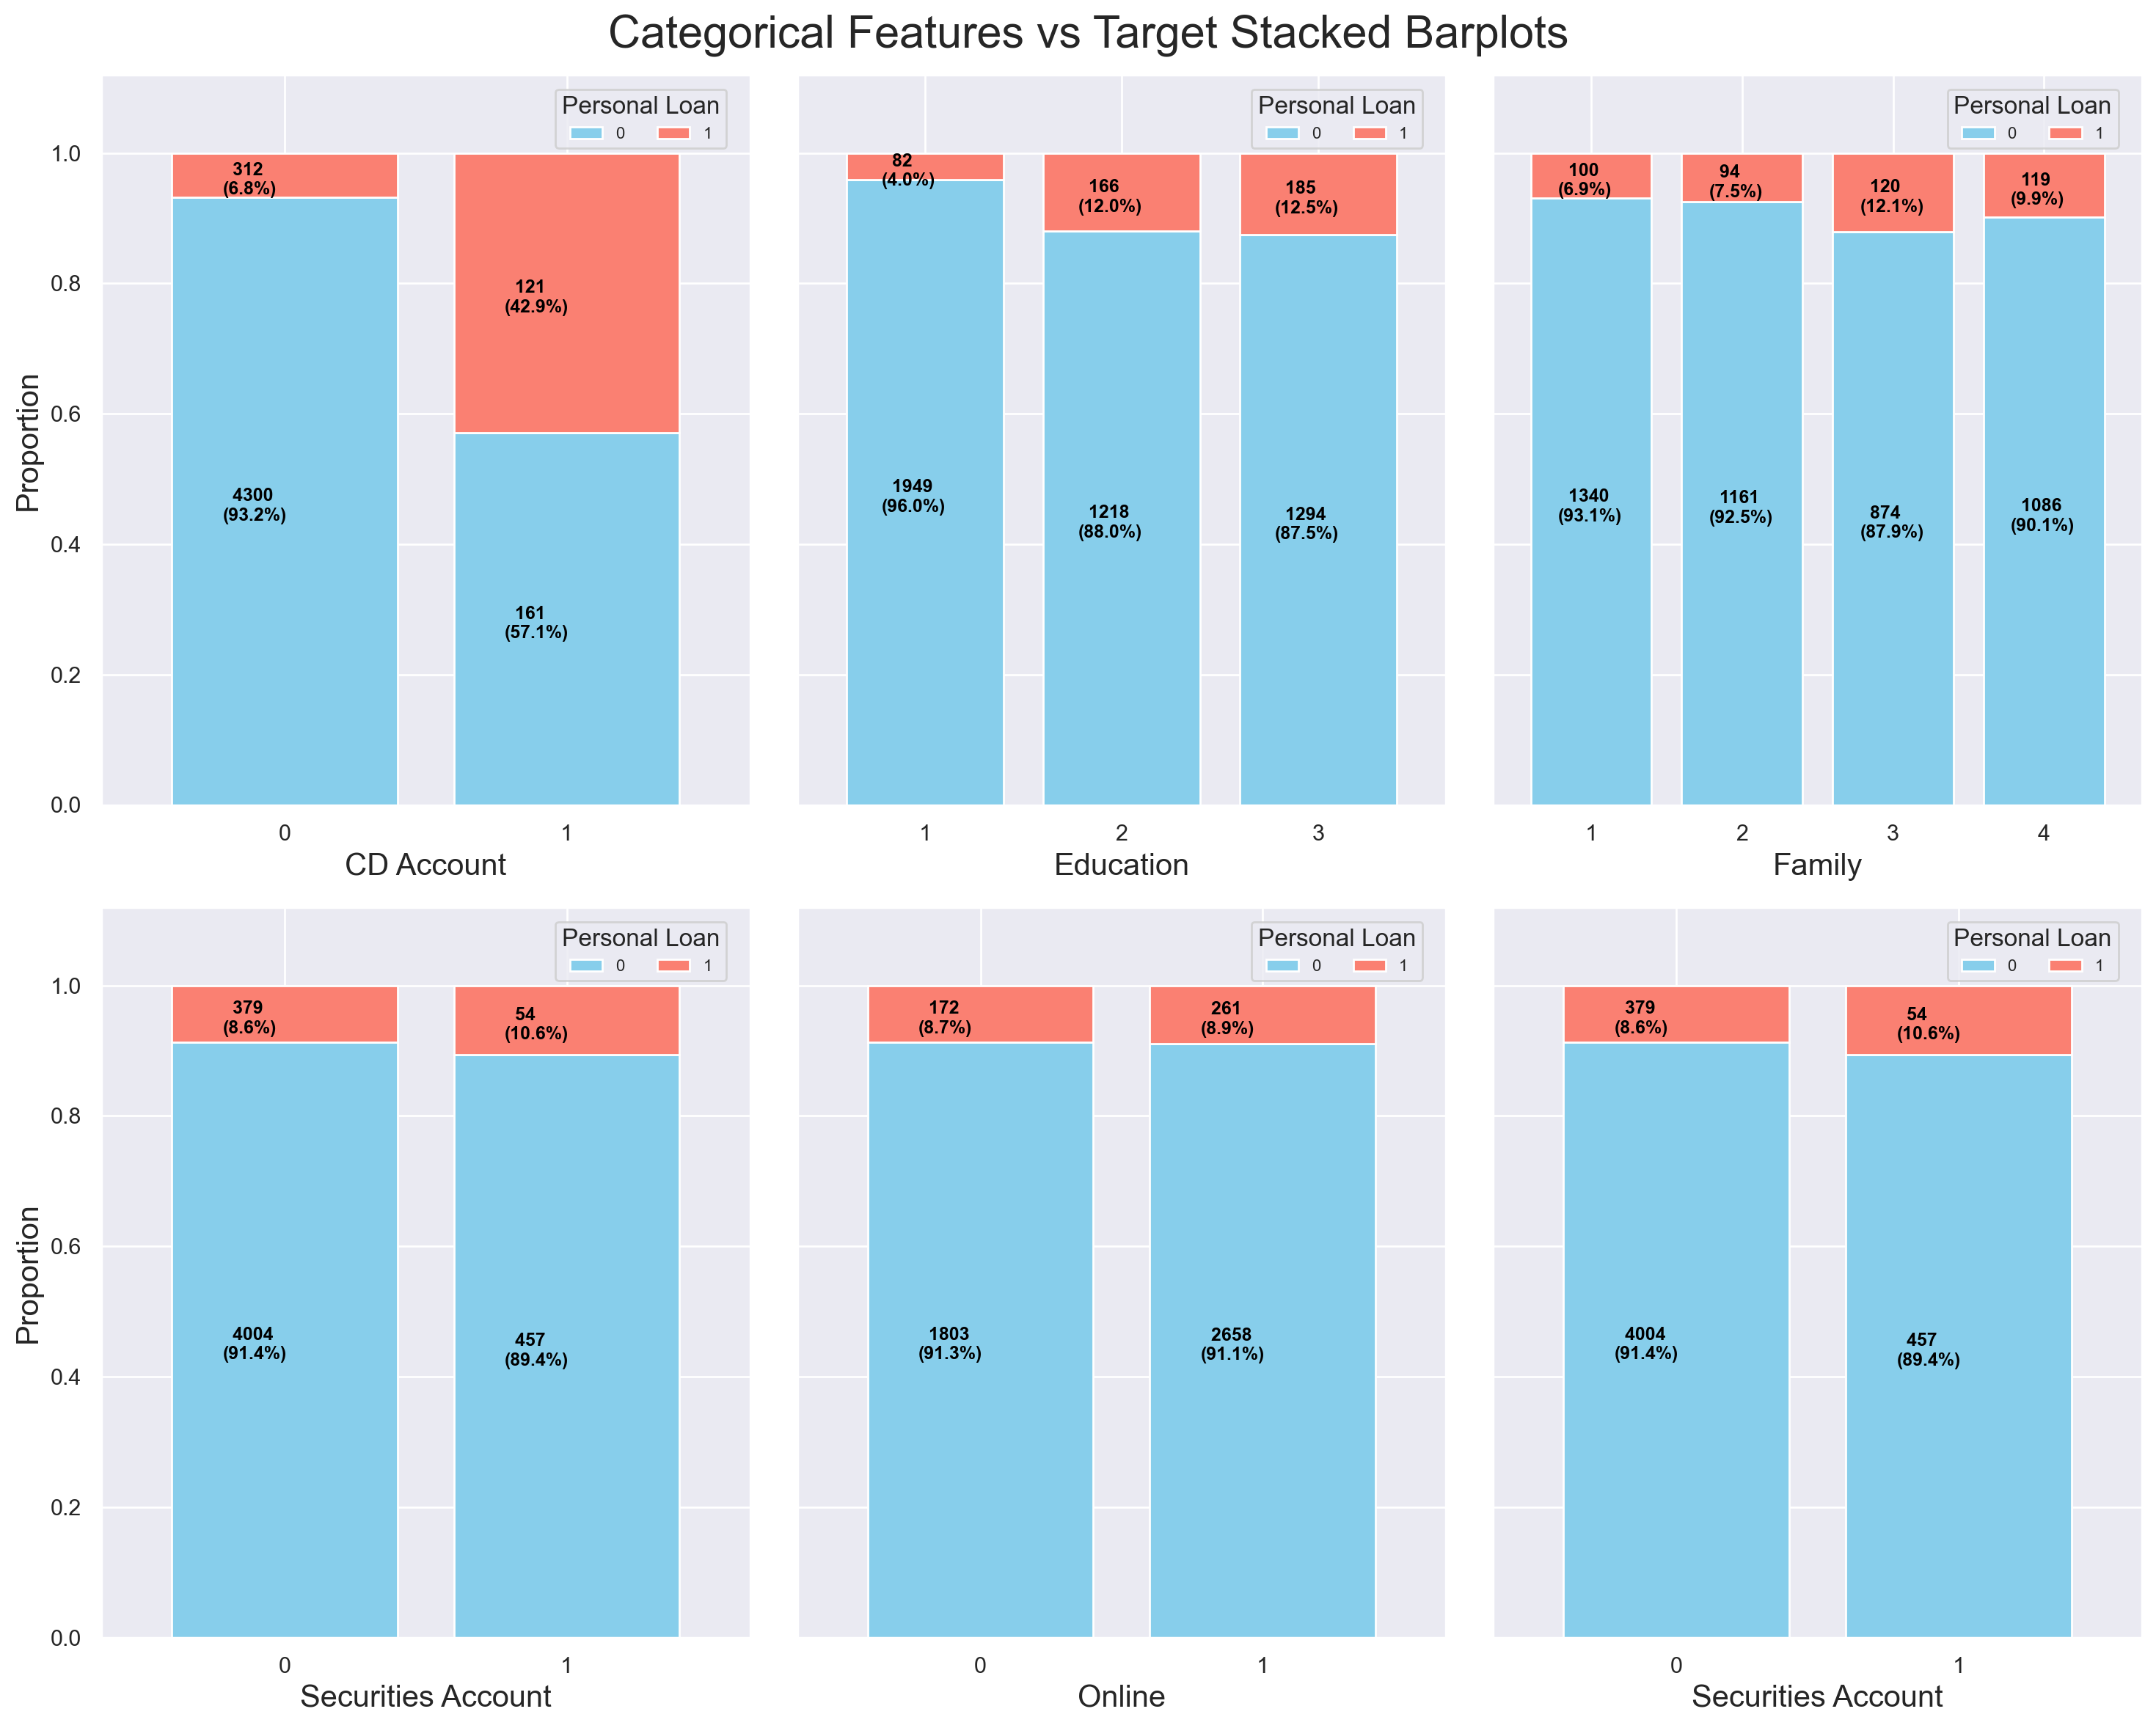

In [118]:
## Bivariate Analysis - Categorical vs.Target
# Define a list containing the names of important categorical features in the dataset 
Cat_Features = ['CD Account','Education','Family','Securities Account','Online','Securities Account']

# Define the target name in a variable for simplicity
Target = 'Personal Loan'

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,12), dpi=200)

for i,col in enumerate(Cat_Features):
    
    # Create a cross tabulation showing the proportion of purchased and non-purchased loans for each category of the feature
    cross_tab = pd.crosstab(index=df[col], columns=df[Target])
    
    # Using the normalize=True argument gives us the index-wise proportion of the data
    cross_tab_prop = pd.crosstab(index=df[col], columns=df[Target], normalize='index')

    # Define colormap
    cmp = ListedColormap(['skyblue', 'salmon'])
    
    # Plot stacked bar charts
    x, y = i//3, i%3
    cross_tab_prop.plot(kind='bar', ax=ax[x,y], stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)
    
    # Add the proportions and counts of the individual bars to our plot
    for idx, val in enumerate([*cross_tab.index.values]):
        for (proportion, count, y_location) in zip(cross_tab_prop.loc[val],cross_tab.loc[val],cross_tab_prop.loc[val].cumsum()):
            ax[x,y].text(x=idx-0.22, y=(y_location-proportion)+(proportion/2)-0.03,
                         s = f'  {count}\n({np.round(proportion * 100, 1)}%)', 
                         color = "black", fontsize=9, fontweight="bold")
    
    # Add legend
    ax[x,y].legend(title='Personal Loan', loc=(0.7,0.9), fontsize=8, ncol=2)
    # Set y limit
    ax[x,y].set_ylim([0,1.12])
    # Rotate xticks
    ax[x,y].set_xticklabels(ax[x,y].get_xticklabels(), rotation=0)
            

plt.suptitle('Categorical Features vs Target Stacked Barplots', fontsize=22)
plt.tight_layout()                     
plt.show()

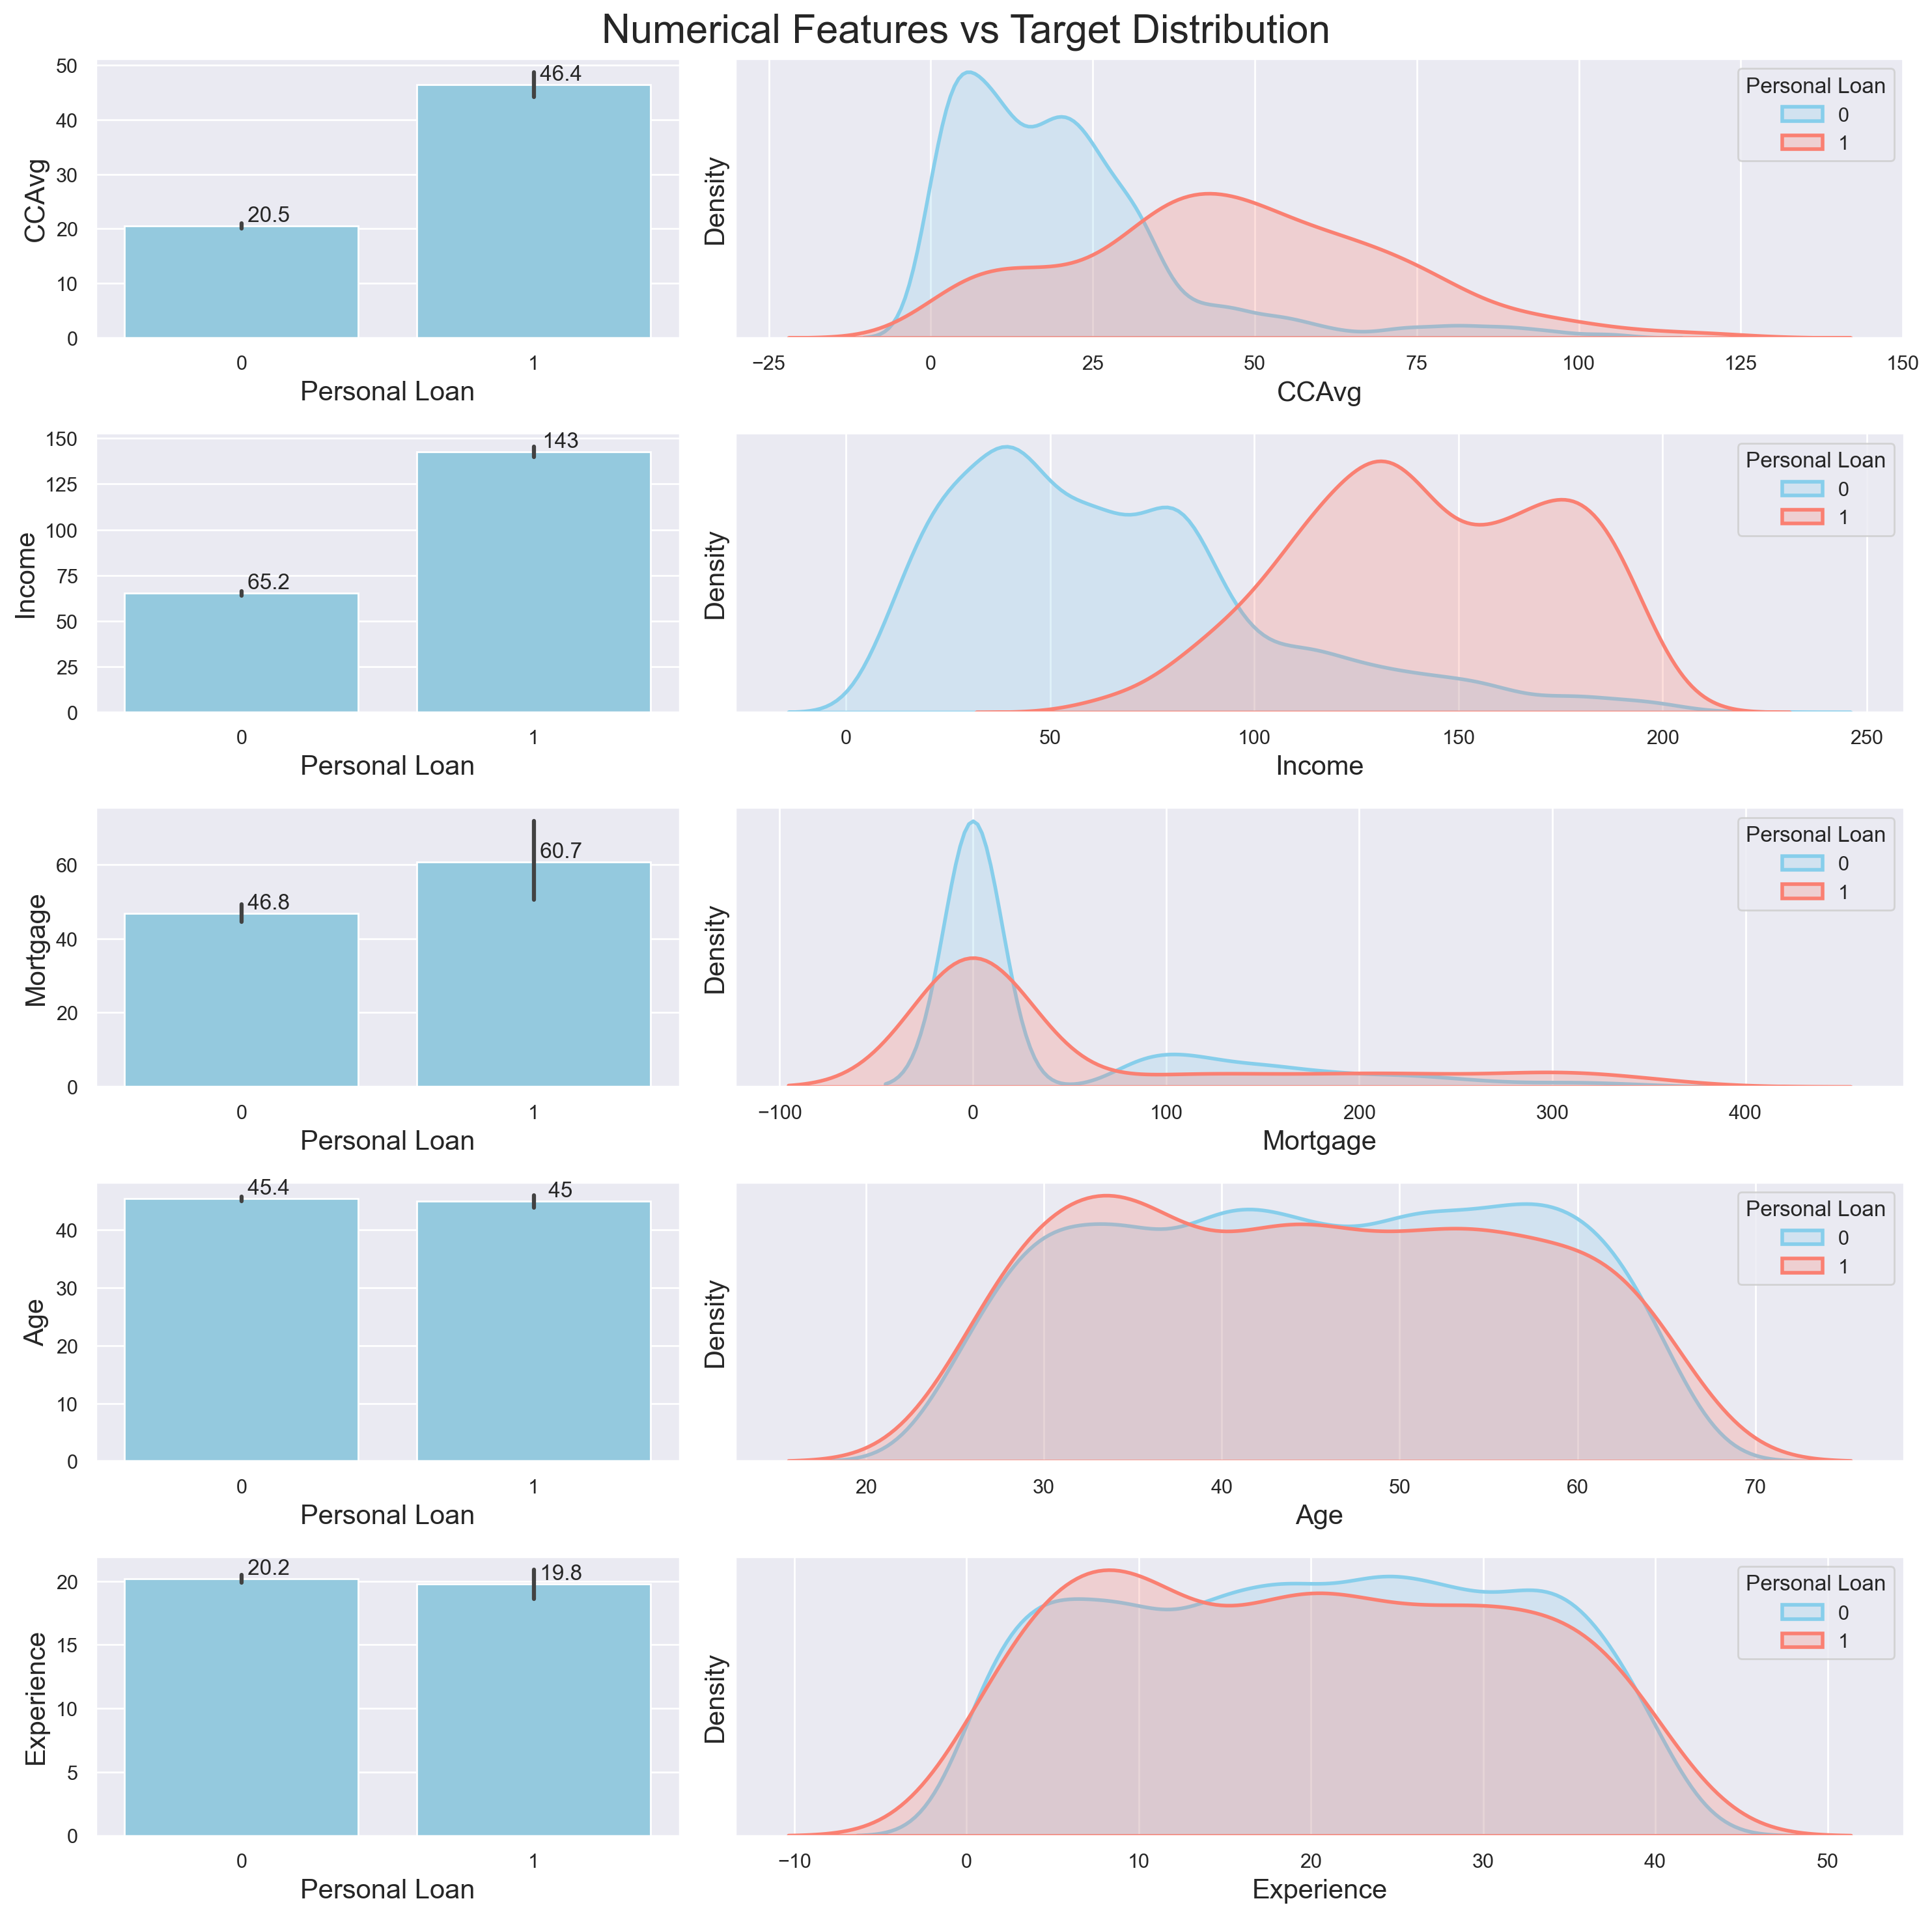

In [119]:
### Numerical features vs target
Num_Features = ['CCAvg','Income','Mortgage','Age','Experience']
sns.set_palette(['skyblue', 'salmon'])

fig, ax = plt.subplots(5, 2, figsize=(15,15), dpi=200, gridspec_kw={'width_ratios': [1, 2]})

for i,col in enumerate(Num_Features):
    # barplot
    graph = sns.barplot(data=df, x=Target, y=col, ax=ax[i,0])
    # kde Plot
    sns.kdeplot(data=df[df[Target]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=df[df[Target]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Personal Loan', loc='upper right')
    # Add bar sizes to our plot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')
        
plt.suptitle('Numerical Features vs Target Distribution', fontsize=22)
plt.tight_layout()                     
plt.show()

In [120]:
#The distribution of the Experience is very similar to the distribution of Age, as Experience is strongly correlated with Age. 
#Therefore, we remove Experience because it doesn't provide any more information than Age:
df.drop('Experience', axis=1, inplace=True)

### Advanced Analysis

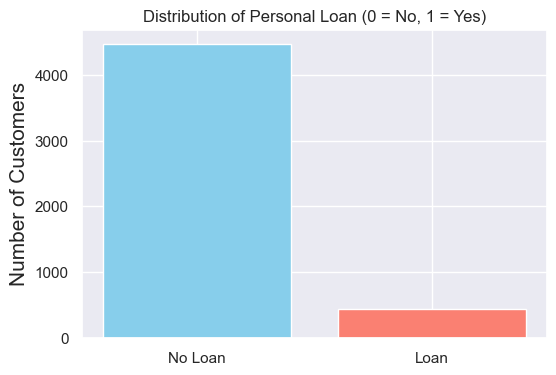

In [121]:
## We noticed that the distribution of response is imbalance as it has many customers who has no loan compared to the customers who has loans.
## Distribution of the Response variable

# Count of each category
counts = df['Personal Loan'].value_counts()

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['skyblue','salmon'])
plt.xticks([0,1], ['No Loan', 'Loan'])
plt.ylabel("Number of Customers")
plt.title("Distribution of Personal Loan (0 = No, 1 = Yes)")
plt.show()

### Encode Categorical Variables

In [122]:
def encode_objects(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

df = df.apply(lambda x: encode_objects(x))
df.head()

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,82,4,19.2,0,0,0,1,0,0,0
1,45,34,33,3,18.0,0,0,0,1,0,0,0
2,39,11,366,1,12.0,0,0,0,0,0,0,0
3,35,100,297,1,32.4,1,0,0,0,0,0,0
4,35,45,95,4,12.0,1,0,0,0,0,0,1


### Split Data into Train and Test Set

In [150]:
X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan'] 

In [151]:
# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [152]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((3915, 11), (979, 11), (3915,), (979,))

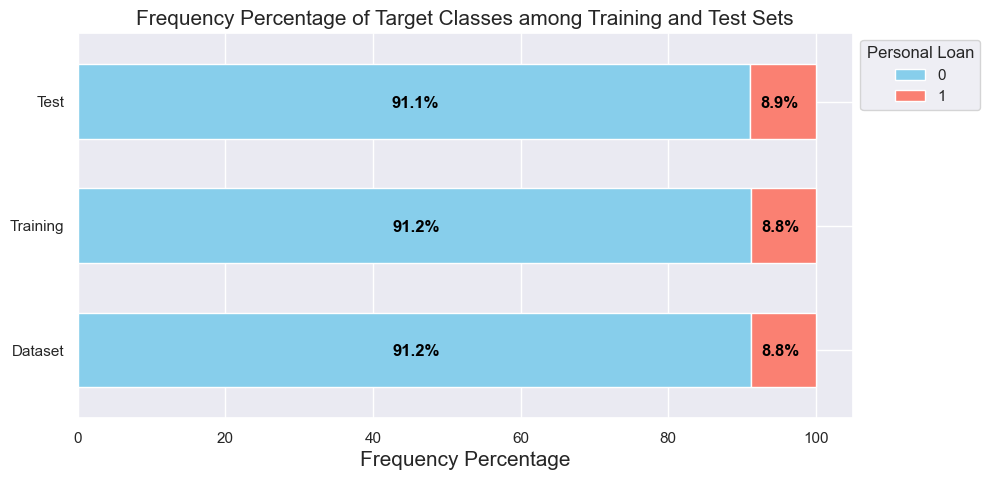

In [153]:
# Define a dataframe containing frequency percentages
df_perc = pd.concat([y.value_counts(normalize=True).mul(100).round(1),
                     y_train.value_counts(normalize=True).mul(100).round(1),
                     y_test.value_counts(normalize=True).mul(100).round(1)], axis=1)
df_perc.columns=['Dataset','Training','Test']
df_perc = df_perc.T

# Plot frequency percentages barplot
df_perc.plot(kind='barh', stacked=True, figsize=(10,5), width=0.6)

# Add the percentages to our plot
for idx, val in enumerate([*df_perc.index.values]):
    for (percentage, y_location) in zip(df_perc.loc[val], df_perc.loc[val].cumsum()):
        plt.text(x=(y_location - percentage) + (percentage / 2)-3,
                 y=idx - 0.05,
                 s=f'{percentage}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.legend(title='Personal Loan', loc=(1.01,0.8))
plt.xlabel('Frequency Percentage', fontsize=15)
plt.title('Frequency Percentage of Target Classes among Training and Test Sets', fontsize=15)
plt.show()

### Encode and Standardize variables

In [154]:
# Define column types
numeric_features = ['Age','Income','Family'	,'CCAvg','Mortgage']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [155]:
X_train

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
1372,1.097207,0.074829,159,-1.213882,-0.285035,2,-0.578206,0,0,1,0
1662,-0.034167,1.536579,76,-0.341731,3.381736,0,0.995986,0,0,0,0
4776,-0.208224,0.029852,311,0.530419,0.266952,0,-0.578206,1,1,1,1
2791,0.313948,0.164783,276,1.402569,1.016077,2,1.950043,0,0,1,0
2174,1.706408,0.187272,291,-1.213882,-0.639883,2,-0.578206,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6,0.662063,0.007364,114,-0.341731,-0.225893,1,-0.578206,0,0,1,0
3075,-1.687713,-0.937151,275,1.402569,-0.344176,2,-0.578206,0,0,1,1
1807,-0.208224,-0.150055,237,-0.341731,0.188097,2,-0.578206,0,0,1,0
1745,0.575034,-1.184524,64,-0.341731,-0.699025,1,-0.578206,0,0,0,1


In [156]:
### Identify best features
# Define a scorer function
def f1_metric(model, X_train, y_train):
    '''
    This function reports f1-score metric for the class specified by 'Positive Label' (or '1')
    '''
    return f1_score(y_train, model.predict(X_train), average='binary')

def drop_column_importance(model, X_train, y_train, random_state=0):
    # list containing feature importances
    importances = []
    # Clone the model
    model_clone = clone(model)
    # Set random_state for comparability
    model_clone.random_state = random_state
    # Train the model
    model_clone.fit(X_train, y_train)
    # Create the cross-validation object using StratifiedKFold 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    # Score the benchmark model using cross-validation
    benchmark_score = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring=f1_metric).mean()

    
    # Iterate over all features and store feature importance
    for col in X_train.columns:
        # Clone the model
        model_clone = clone(model)
        # Set random_state for comparability
        model_clone.random_state = random_state
        # Traint the model on the the dataset with a single feature removed
        model_clone.fit(X_train.drop(col, axis = 1), y_train)
        # Score the droped-column model
        drop_column_score = cross_val_score(model_clone, X_train.drop(col,axis=1), y_train, cv=cv, scoring=f1_metric).mean()
        # Store feature importance which is defined as the difference between the benchmark and the new model score
        importances.append(benchmark_score - drop_column_score)
        
    # Return the features along with their importances in the form of a dataframe
    importances_df = pd.DataFrame({'feature': X_train.columns, 'feature importance': importances}) \
                     .sort_values('feature importance', ascending = False).reset_index(drop = True)
           
    return importances_df                  

def drop_column_importance_plot(model, X_train, y_train):
    # Call drop-column feature importance function
    df_drop_column = drop_column_importance(model, X_train, y_train, random_state=0)
    # Rename columns
    df_drop_column.columns = ['Feature', 'Feature Importance']
    
    # Plot barchart
    plt.figure(figsize=(8,5))
    sns.barplot(data=df_drop_column, x='Feature Importance', y='Feature', orient='h', color='royalblue')
    plt.title('Drop Column Feature Importance', fontsize=10)
    plt.show()

### Logistic Regression

In [157]:
## Fit Logistic Regression Model without parameter tuning or feature selection
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42,max_iter=1000)
lr_model = lr.fit(X_train, y_train)
y_predicted = lr_model.predict(X_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('LogReg: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       892
           1       0.75      0.59      0.66        87

    accuracy                           0.95       979
   macro avg       0.86      0.78      0.81       979
weighted avg       0.94      0.95      0.94       979

LogReg: ROC AUC =  78.4 %
LogReg: Precision =  75.0 %
LogReg: Recall =  58.6 %
LogReg: Accuracy =  94.6 %
LogReg: F1-Score =  65.8 %


array([[875,  17],
       [ 36,  51]])

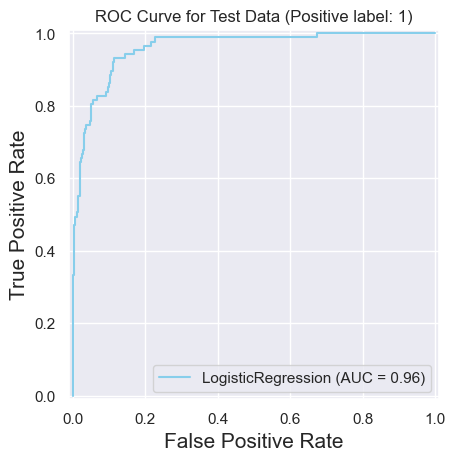

In [158]:
# Plot ROC curve for test data and display AUC score 
RocCurveDisplay.from_estimator(lr_model, X_test, y_test)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Test Data (Positive label: 1)')
plt.show()

In [159]:
# Generate classification report for training set
y_pred_train = lr_model.predict(X_train)
print("\n\t  Classification report for training set")
print("-"*55)
print(classification_report(y_train, y_pred_train))



	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3569
           1       0.82      0.63      0.71       346

    accuracy                           0.96      3915
   macro avg       0.89      0.81      0.84      3915
weighted avg       0.95      0.96      0.95      3915



In [160]:
# Model
log_reg = LogisticRegression(max_iter=1000)
class_weights = [{0:x, 1:1.0-x} for x in np.linspace(0.001,0.5,20)]
# Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports both l1 & l2
    'class_weight': class_weights
}

# Grid Search
grid = GridSearchCV(estimator=log_reg,
                    param_grid=param_grid,
                    cv=5,
                    scoring='f1',   # good for imbalance
                    n_jobs=-1)

grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'class_weight': {0: np.float64(0.5), 1: np.float64(0.5)}, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.7125167858161267


In [161]:
# Initialize model with best parameters
best_params = grid.best_params_
lr_tuned_Parameters = LogisticRegression(**best_params)
lr_tuned_Parameters.fit(X_train, y_train)

y_predicted = lr_tuned_Parameters.predict(X_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('LogReg: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       892
           1       0.74      0.60      0.66        87

    accuracy                           0.95       979
   macro avg       0.85      0.79      0.82       979
weighted avg       0.94      0.95      0.94       979

LogReg: ROC AUC =  78.9 %
LogReg: Precision =  74.3 %
LogReg: Recall =  59.8 %
LogReg: Accuracy =  94.6 %
LogReg: F1-Score =  66.2 %


array([[874,  18],
       [ 35,  52]])

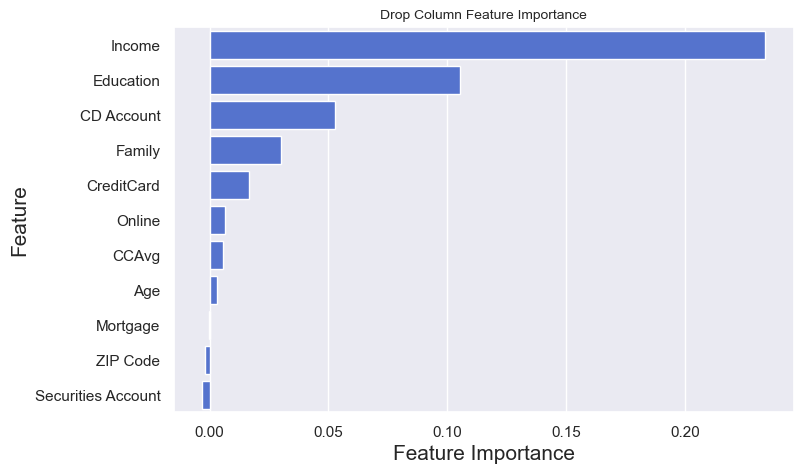

In [162]:
drop_column_importance_plot(lr_tuned_Parameters, X_train, y_train)

In [163]:
X_train.columns

Index(['Age', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [164]:
cols = ['Mortgage','Age', 'Income', 'Family', 'CCAvg', 'Education', 'CD Account', 'Online', 'CreditCard']
nw_train = X_train[cols]
nw_test = X_test[cols]
lr_tuned_Parameters.fit(nw_train, y_train)

y_predicted = lr_tuned_Parameters.predict(nw_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('LogReg: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('LogReg: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       892
           1       0.73      0.56      0.64        87

    accuracy                           0.94       979
   macro avg       0.84      0.77      0.80       979
weighted avg       0.94      0.94      0.94       979

LogReg: ROC AUC =  77.2 %
LogReg: Precision =  73.1 %
LogReg: Recall =  56.3 %
LogReg: Accuracy =  94.3 %
LogReg: F1-Score =  63.6 %


array([[874,  18],
       [ 38,  49]])

### Random Forest Model

In [165]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [166]:
y_predicted = rf.predict(X_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('Random Forest: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       892
           1       0.99      0.89      0.93        87

    accuracy                           0.99       979
   macro avg       0.99      0.94      0.96       979
weighted avg       0.99      0.99      0.99       979

Random Forest: ROC AUC =  94.2 %
Random Forest: Precision =  98.7 %
Random Forest: Recall =  88.5 %
Random Forest: Accuracy =  98.9 %
Random Forest: F1-Score =  93.3 %


array([[891,   1],
       [ 10,  77]])

In [167]:
# Generate classification report for training set
y_pred_train = rf.predict(X_train)
print("\n\t  Classification report for training set")
print("-"*55)
print(classification_report(y_train, y_pred_train))



	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3569
           1       1.00      1.00      1.00       346

    accuracy                           1.00      3915
   macro avg       1.00      1.00      1.00      3915
weighted avg       1.00      1.00      1.00      3915



In [168]:
from sklearn.model_selection import RandomizedSearchCV
# Weights associated with classes
class_weights = [{0:x, 1:1.0-x} for x in np.linspace(0.001,1,20)]

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150], 
    'max_depth': np.arange(5, 12),
    'min_samples_split': [1, 2, 3],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': class_weights
}
rf_random = RandomizedSearchCV(estimator = rf,param_distributions = param_grid,
               n_iter = 10, cv = 5, verbose=2, random_state=35, n_jobs = -1)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    vali

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'class_weight': [{0: np.float64(0.001),
                                                          1: np.float64(0.999)},
                                                         {0: np.float64(0.05357894736842105),
                                                          1: np.float64(0.9464210526315789)},
                                                         {0: np.float64(0.1061578947368421),
                                                          1: np.float64(0.8938421052631579)},
                                                         {0: np.float64(0.15873684210526315),
                                                          1: np.float64(0.841263157894736...
                                                          1: np.float64(0.15773684210526318)},
                                                         {0: np.float64(0.8948421052631579),
                                                          1: np.float64(0.10515789473684212)},
                                                         {0: np.float64(0.9474210526315789),
                                                          1: np.float64(0.05257894736842106)},
                                                         {0: np.float64(1.0),
                                                          1: np.float64(0.0)}],
                                        'max_depth': array([ 5,  6,  7,  8,  9, 10, 11]),
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [1, 2, 3],
                                        'n_estimators': [50, 100, 150]},
                   random_state=35, verbose=2)

In [169]:
best_params_rf = rf_random.best_params_

In [170]:
tune_rf = RandomForestClassifier(**best_params_rf)
tune_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: np.float64(0.3164736842105263),
                                     1: np.float64(0.6835263157894738)},
                       max_depth=np.int64(10), min_samples_leaf=3,
                       min_samples_split=3, n_estimators=150)

In [171]:
y_predicted = tune_rf.predict(X_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('Random Forest: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       892
           1       0.97      0.90      0.93        87

    accuracy                           0.99       979
   macro avg       0.98      0.95      0.96       979
weighted avg       0.99      0.99      0.99       979

Random Forest: ROC AUC =  94.7 %
Random Forest: Precision =  97.5 %
Random Forest: Recall =  89.7 %
Random Forest: Accuracy =  98.9 %
Random Forest: F1-Score =  93.4 %


array([[890,   2],
       [  9,  78]])

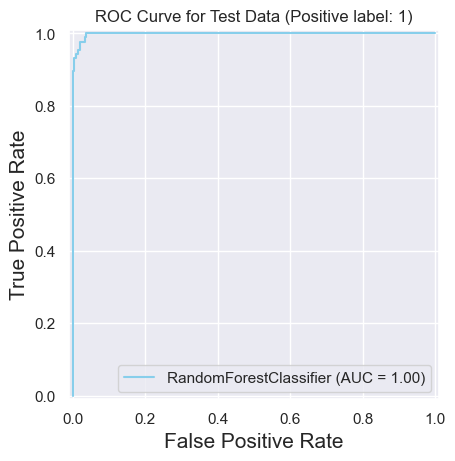

In [172]:
# Plot ROC curve for test data and display AUC score 
RocCurveDisplay.from_estimator(tune_rf, X_test, y_test)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Test Data (Positive label: 1)')
plt.show()

In [173]:
# Generate classification report for training set
y_pred_train = tune_rf.predict(X_train)
print("\n\t  Classification report for training set")
print("-"*55)
print(classification_report(y_train, y_pred_train))


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3569
           1       0.98      0.96      0.97       346

    accuracy                           0.99      3915
   macro avg       0.99      0.98      0.98      3915
weighted avg       0.99      0.99      0.99      3915



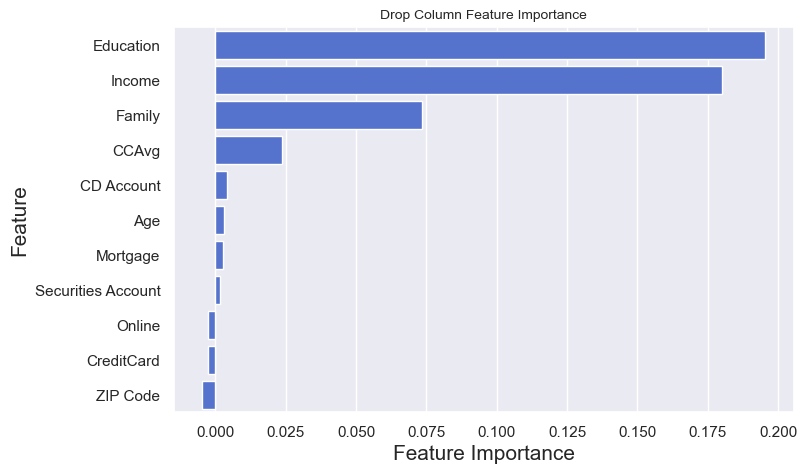

In [174]:
drop_column_importance_plot(tune_rf, X_train, y_train)

In [175]:
X_train.columns

Index(['Age', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [176]:
cols = ['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage','Securities Account', 'CD Account']
nw_train = X_train[cols]
nw_test = X_test[cols]

tune_rf.fit(nw_train, y_train)

y_predicted = tune_rf.predict(nw_test)

print('\nclassification report')
print(classification_report(y_test, y_predicted)) # generate the precision, recall, f-1 score, num
print('Random Forest: ROC AUC = ',str(round(roc_auc_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Precision = ',str(round(precision_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Recall = ',str(round(recall_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: Accuracy = ',str(round(accuracy_score(y_test, y_predicted)*100,1)), '%')
print('Random Forest: F1-Score = ',str(round(f1_score(y_test, y_predicted)*100,1)), '%')
confusion_matrix(y_test, y_predicted)


classification report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       892
           1       0.98      0.92      0.95        87

    accuracy                           0.99       979
   macro avg       0.98      0.96      0.97       979
weighted avg       0.99      0.99      0.99       979

Random Forest: ROC AUC =  95.9 %
Random Forest: Precision =  97.6 %
Random Forest: Recall =  92.0 %
Random Forest: Accuracy =  99.1 %
Random Forest: F1-Score =  94.7 %


array([[890,   2],
       [  7,  80]])

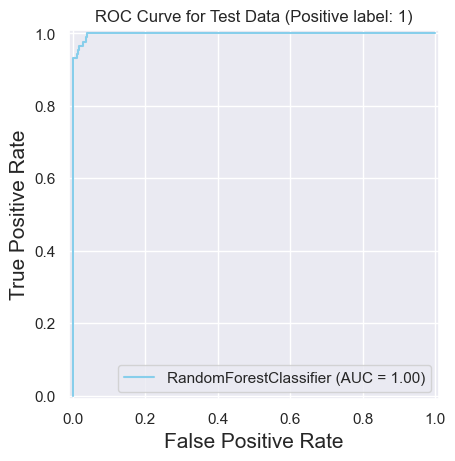

In [177]:
# Plot ROC curve for test data and display AUC score 
RocCurveDisplay.from_estimator(tune_rf, nw_test, y_test)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Test Data (Positive label: 1)')
plt.show()

In [179]:
y_pred_train = tune_rf.predict(nw_train)
print("\n\t  Classification report for training set")
print("-"*55)
print(classification_report(y_train, y_pred_train))


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3569
           1       0.98      0.95      0.96       346

    accuracy                           0.99      3915
   macro avg       0.99      0.97      0.98      3915
weighted avg       0.99      0.99      0.99      3915



### KNN Model

In [181]:
#KNN classifier
from sklearn.neighbors import KNeighborsClassifier

accuracy=[]
for i in range(2,30):
    knn= KNeighborsClassifier(n_neighbors=i,metric="minkowski",p=2)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(y_test,y_pred)*100)

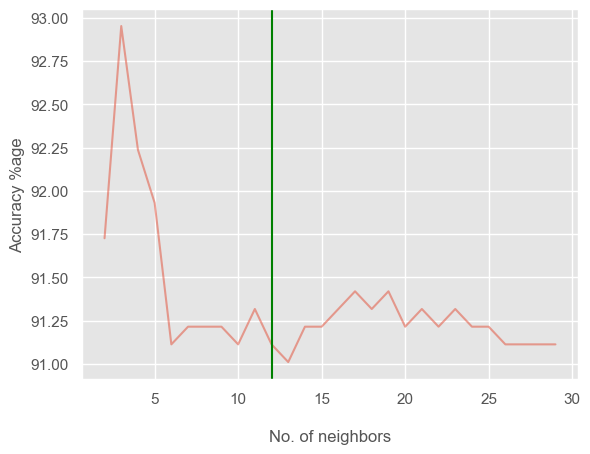

In [182]:
plt.style.use("ggplot")
plt.plot(range(2,30),accuracy,alpha=0.5)
plt.axvline(12,color="green")
plt.xlabel("\nNo. of neighbors")
plt.ylabel("Accuracy %age")
plt.show()

In [184]:
knn_model = KNeighborsClassifier(n_neighbors = 12) 
knn_model.fit(X_train,y_train)
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)

predicted_knn = knn_model.predict(X_test)
report = classification_report(y_test,predicted_knn)
print(report)

KNN accuracy: 0.9111338100102145
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       892
           1       0.50      0.03      0.06        87

    accuracy                           0.91       979
   macro avg       0.71      0.52      0.51       979
weighted avg       0.88      0.91      0.87       979



In [187]:
# Define hyperparameters grid to search
param_grid = [{'n_neighbors': np.arange(2, 30), 'metric': ['euclidean','manhattan'], 'weights': ['uniform']},
              {'n_neighbors': np.arange(2, 30), 'metric': ['minkowski'], 'p': [3,4,5], 'weights': ['uniform']}]

# Create a KNN classifier object
knn = KNeighborsClassifier()

# Create the cross-validation object using StratifiedKFold to ensure the class distribution is the same across all the folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Create the GridSearchCV object
knn_grid = GridSearchCV(knn, param_grid, cv=cv, scoring=f1_metric, n_jobs=-1)

# Fit the GridSearchCV object to the training data
knn_grid.fit(X_train, y_train)

# Get the best hyperparameters
print("Best hyperparameters:\n", knn_grid.best_params_)
    

Best hyperparameters:
 {'metric': 'manhattan', 'n_neighbors': np.int64(3), 'weights': 'uniform'}


In [188]:
## Fit KNN with best hyperparameters

knn_tuned = KNeighborsClassifier(**knn_grid.best_params_)
# Fit the model
knn_tuned.fit(X_train, y_train)

# Make predictions
y_pred_tuned= knn_tuned.predict(X_test)
report = classification_report(y_test,y_pred_tuned)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       892
           1       0.72      0.21      0.32        87

    accuracy                           0.92       979
   macro avg       0.82      0.60      0.64       979
weighted avg       0.91      0.92      0.90       979



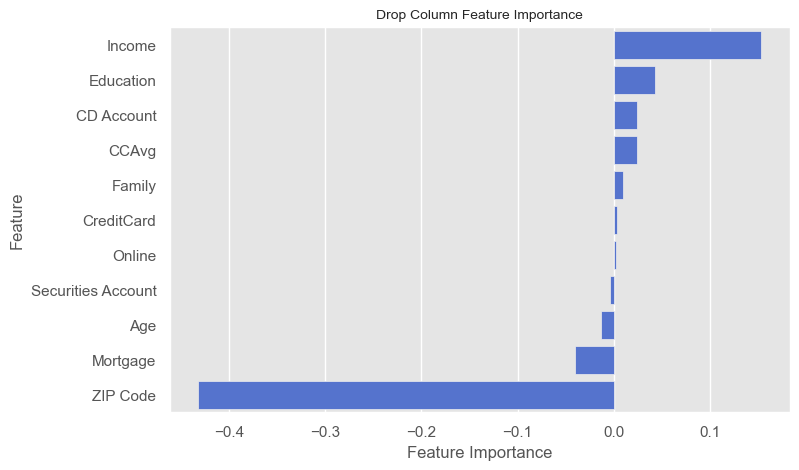

In [189]:
drop_column_importance_plot(knn_tuned, X_train, y_train)

In [193]:
cols = ['Online', 'CreditCard', 'Family', 'CCAvg', 'Education', 'Income', 'CD Account']
nw_train_knn = X_train[cols]
nw_test_knn = X_test[cols]

knn_tuned.fit(nw_train_knn, y_train)

y_predicted_knn = knn_tuned.predict(nw_test_knn)
report = classification_report(y_test,y_predicted_knn)
print(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       892
           1       0.94      0.77      0.85        87

    accuracy                           0.98       979
   macro avg       0.96      0.88      0.92       979
weighted avg       0.97      0.98      0.97       979

